<a href="https://colab.research.google.com/github/Rabiatou08/DI-Bootcamp/blob/main/week2/Day4/Dailychallenges/defi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Défi quotidien : Analyse stratégique des performances des supermarchés


In [6]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [10]:
import pandas as pd

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [11]:
print(df.shape)

print(df.columns.tolist())

df.info()

(9994, 21)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  R

In [12]:
# Doublons
print("Doublons :", df.duplicated().sum())

df = df.drop_duplicates()

# Valeurs manquantes
print(df.isnull().sum())

Doublons : 0
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [15]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print(df[['Order Date','Ship Date']].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [17]:
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

df['Order Year'] = df['Order Date'].dt.year

df['Order Month'] = df['Order Date'].dt.month

df['Order Month-Year'] = df['Order Date'].dt.to_period('M')

df[['Sales',
    'Profit',
    'Profit Margin',
    'Order Year',
    'Order Month']].head()

,Sales,Profit,Profit Margin,Order Year,Order Month
0,261.9600,41.9136,16.00,2016,11
1,731.9400,219.5820,30.00,2016,11
2,14.6200,6.8714,47.00,2016,6
3,957.5775,-383.0310,-40.00,2015,10
4,22.3680,2.5164,11.25,2015,10


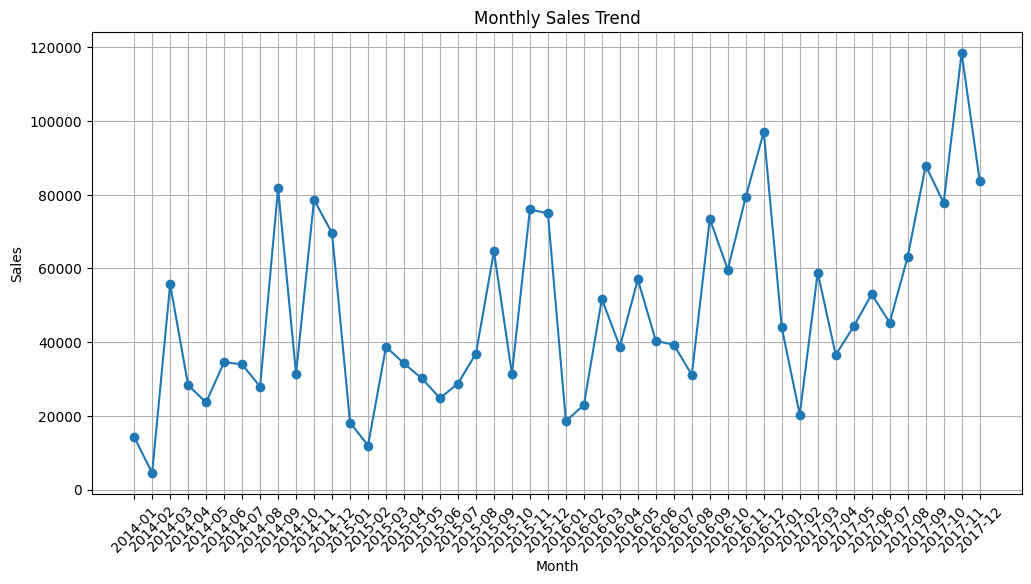

In [18]:
monthly_sales = (
    df.groupby('Order Month-Year')['Sales']
      .sum()
)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.xticks(rotation=45)
plt.grid()

plt.show()

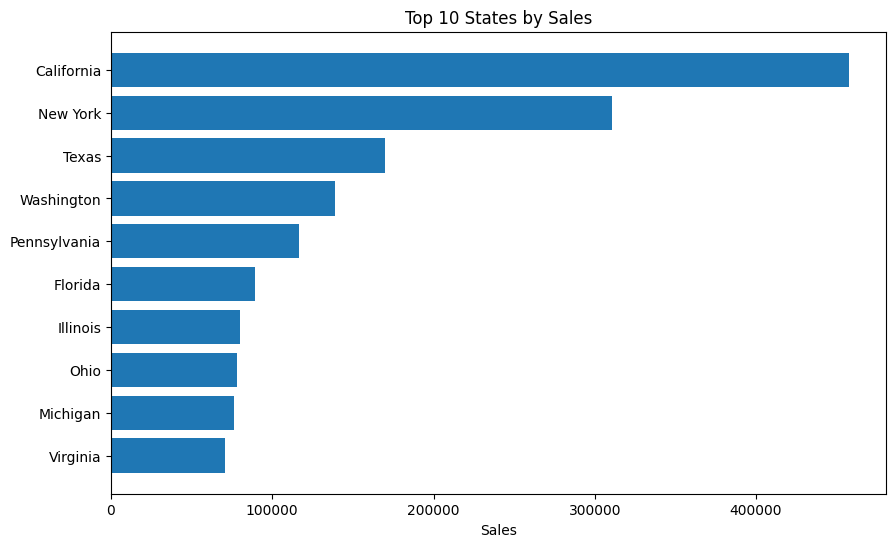

In [19]:
state_sales = (
    df.groupby('State')['Sales']
      .sum()
      .sort_values()
)

top10 = state_sales.tail(10)

plt.figure(figsize=(10,6))

plt.barh(top10.index, top10.values)

plt.title('Top 10 States by Sales')

plt.xlabel('Sales')

plt.show()

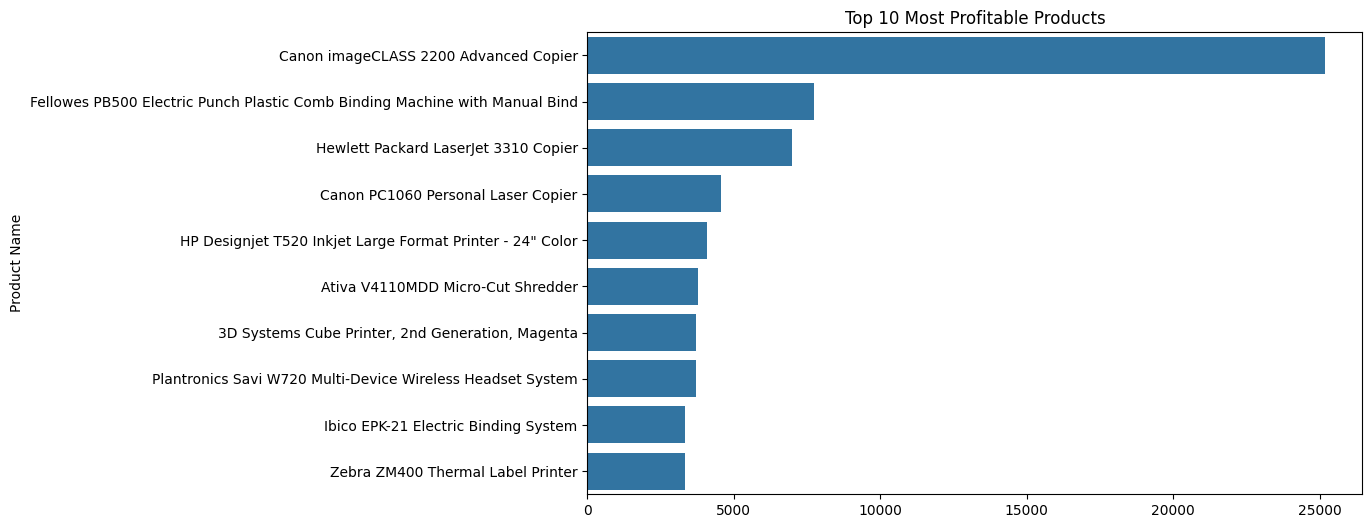

In [20]:
product_profit = (
    df.groupby('Product Name')['Profit']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=product_profit.values,
    y=product_profit.index
)

plt.title('Top 10 Most Profitable Products')

plt.show()

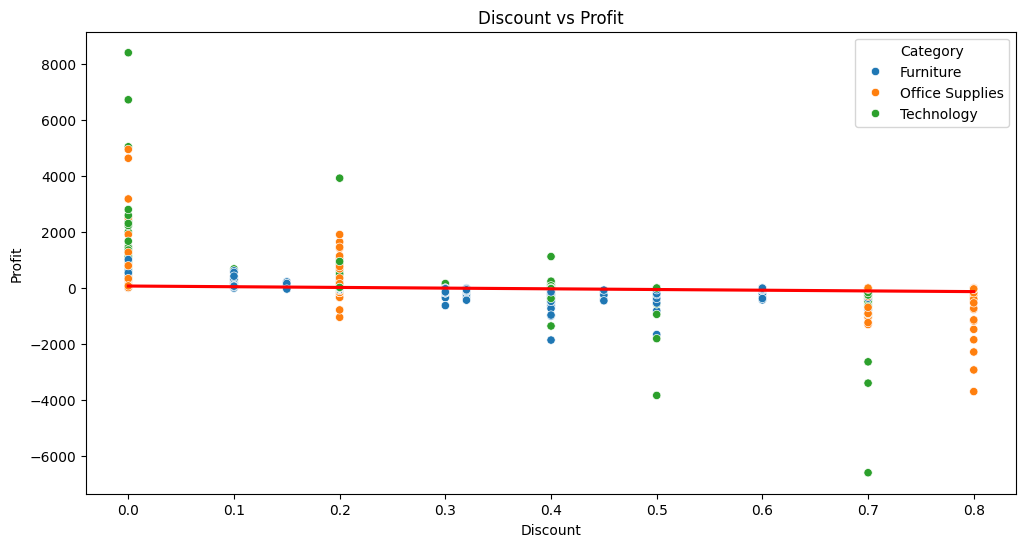

In [21]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    hue='Category'
)

sns.regplot(
    data=df,
    x='Discount',
    y='Profit',
    scatter=False,
    color='red'
)

plt.title('Discount vs Profit')

plt.show()

In [22]:
total_sales = df['Sales'].sum()

total_profit = df['Profit'].sum()

top_state = (
    df.groupby('State')['Sales']
      .sum()
      .idxmax()
)

top_product = (
    df.groupby('Product Name')['Profit']
      .sum()
      .idxmax()
)

print("=== EXECUTIVE SUMMARY ===")

print(f"\nTotal Revenue : ${total_sales:,.2f}")

print(f"\nTotal Profit : ${total_profit:,.2f}")

print(f"\nBest State : {top_state}")

print(f"\nMost Profitable Product : {top_product}")

print("\nRecommendation :")
print("- Focus on profitable products.")
print("- Monitor discounts carefully.")
print("- Reinforce sales strategy in top-performing states.")

=== EXECUTIVE SUMMARY ===

Total Revenue : $2,297,200.86

Total Profit : $286,397.02

Best State : California

Most Profitable Product : Canon imageCLASS 2200 Advanced Copier

Recommendation :
- Focus on profitable products.
- Monitor discounts carefully.
- Reinforce sales strategy in top-performing states.


# Executive Summary

## Key Findings

- Total Revenue: $2,297,200.86
- Total Profit: $286,397.02
- California is the best performing state by sales.
- Canon imageCLASS 2200 Advanced Copier is the most profitable product.
- Higher discounts tend to reduce profitability.
- Discount strategies should be carefully monitored to avoid losses.

## Recommendations

1. Focus marketing efforts on high-profit products.
2. Limit excessive discounts.
3. Strengthen operations in top-performing states.
4. Analyze underperforming regions for improvement opportunities.